In [ ]:
# БЛОК 1: Импорт библиотек
import time
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from random import randint
from scipy import stats
from scipy.optimize import curve_fit

# Настройка отображения графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
# БЛОК 2: Функции генерации графа
def generate_graph_space(n_zones=10):
    """Создает связный граф с кольцевой структурой и случайными связями"""
    graph = {}
    for i in range(n_zones):
        graph[i] = []
    
    # Создаем кольцевую структуру (базовая связность)
    for i in range(n_zones):
        graph[i].append((i + 1) % n_zones)
        graph[(i + 1) % n_zones].append(i)
    
    # Добавляем случайные дополнительные связи
    for i in range(n_zones):
        additional = randint(0, 2)
        for _ in range(additional):
            j = randint(0, n_zones - 1)
            if j != i and j not in graph[i]:
                graph[i].append(j)
                graph[j].append(i)
    
    return graph

In [3]:
# БЛОК 3: Функции инициализации и проверки доступности
def initialize_game(n_zones=2):
    """Инициализирует структуры данных для игры"""
    graph = generate_graph_space(n_zones)
    zone_values = [randint(1, 100) for _ in range(n_zones)]
    occupied = [0] * n_zones  # 0 - свободна, 1 - P1, 2 - P2
    return graph, zone_values, occupied

def is_zone_available(zone, graph, occupied):
    """Проверяет, может ли игрок занять зону"""
    if occupied[zone] != 0:
        return False
    for neighbor in graph[zone]:
        if occupied[neighbor] != 0:
            return False
    return True

def get_available_zones(graph, occupied):
    """Возвращает список доступных зон"""
    return [zone for zone in range(len(graph)) 
            if is_zone_available(zone, graph, occupied)]

In [4]:
# БЛОК 4: Функции оценки и поиска лучшего хода
def evaluate_zone(zone, zone_values, graph, occupied, player):
    """Оценивает ценность зоны для игрока"""
    score = zone_values[zone]
    
    # Для P2 добавляем бонус за блокировку ценных зон
    if player == 2:
        for neighbor in graph[zone]:
            if occupied[neighbor] == 0 and zone_values[neighbor] > 50:
                score += zone_values[neighbor] * 0.3
    
    return score

def find_best_move(graph, zone_values, occupied, player):
    """Находит лучший ход для игрока"""
    available = get_available_zones(graph, occupied)
    
    if not available:
        return None, 0
    
    best_zone = None
    best_score = -1
    
    for zone in available:
        score = evaluate_zone(zone, zone_values, graph, occupied, player)
        if score > best_score:
            best_score = score
            best_zone = zone
    
    return best_zone, zone_values[best_zone]

In [5]:
# БЛОК 5: Основная функция игры (без визуализации для экспериментов)
def play_game_once(n_zones=10, max_moves_per_player=4, verbose=False):
    """
    Запускает одну игру и возвращает время выполнения
    """
    start_time = time.time()
    
    graph, zone_values, occupied = initialize_game(n_zones)
    
    players = [1, 2]
    current = 0
    scores = {1: 0, 2: 0}
    moves = 0
    total_moves = max_moves_per_player * 2
    
    while moves < total_moves:
        player = players[current]
        zone, value = find_best_move(graph, zone_values, occupied, player)
        
        if zone is None:
            break
        
        occupied[zone] = player
        scores[player] += value
        
        current = (current + 1) % 2
        moves += 1
    
    elapsed_time = time.time() - start_time
    
    if verbose:
        print(f"P1: {scores[1]}, P2: {scores[2]}")
        print(f"Время: {elapsed_time:.4f} сек")
    
    return elapsed_time, scores[1], scores[2]

In [15]:
# БЛОК 6: Визуализация графа (опционально, для наглядности)
def visualize_graph(graph, zone_values, occupied, title="Финальное состояние графа"):
    """Визуализирует состояние графа"""
    G = nx.Graph()
    
    for zone in graph:
        G.add_node(zone, value=zone_values[zone])
    
    for zone, neighbors in graph.items():
        for neighbor in neighbors:
            G.add_edge(zone, neighbor)
    
    plt.figure(figsize=(12, 8))
    
    pos = nx.spring_layout(G, seed=42, k=2, iterations=50)
    
    colors = []
    for zone in G.nodes():
        if occupied[zone] == 0:
            colors.append('lightgray')
        elif occupied[zone] == 1:
            colors.append('lightblue')
        else:
            colors.append('lightcoral')
    
    node_sizes = [zone_values[zone] * 30 for zone in G.nodes()]
    
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=node_sizes, alpha=0.9)
    nx.draw_networkx_edges(G, pos, width=2, alpha=0.5, edge_color='gray')
    
    labels = {}
    for zone in G.nodes():
        owner = ""
        if occupied[zone] == 1:
            owner = "P1"
        elif occupied[zone] == 2:
            owner = "P2"
        labels[zone] = f"{zone}\n({zone_values[zone]})\n{owner}"
    
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')
    
    p1_score = sum(zone_values[z] for z in range(len(occupied)) if occupied[z] == 1)
    p2_score = sum(zone_values[z] for z in range(len(occupied)) if occupied[z] == 2)
    
    plt.title(f"{title}\nP1: {p1_score} очков | P2: {p2_score} очков", fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [19]:
# БЛОК 7: ЭТАП 1 - Эмпирическая оценка времени
def estimate_time_statistics(n_zones=20, num_experiments=100):
    """
    Проводит num_experiments экспериментов и вычисляет
    математическое ожидание и СКО времени выполнения
    """
    print(f"\n{'='*50}")
    print(f"ОЦЕНКА ВРЕМЕНИ ДЛЯ n = {n_zones}")
    print(f"Количество экспериментов: {num_experiments}")
    print(f"{'='*50}")
    
    times = []
    for i in range(num_experiments):
        elapsed, _, _ = play_game_once(n_zones, max_moves_per_player=4, verbose=False)
        times.append(elapsed)
        
        if (i + 1) % 20 == 0:
            print(f"Выполнено {i + 1} экспериментов...")
    
    # Статистические характеристики
    mean_time = np.mean(times)
    std_time = np.std(times, ddof=1)
    min_time = np.min(times)
    max_time = np.max(times)
    
    print(f"\nРезультаты для n = {n_zones}:")
    print(f"  Математическое ожидание: {mean_time:.6f} сек")
    print(f"  Среднеквадратическое отклонение: {std_time:.6f} сек")
    print(f"  Минимальное время: {min_time:.6f} сек")
    print(f"  Максимальное время: {max_time:.6f} сек")
    print(f"  Коэффициент вариации (CV = σ/μ): {std_time/mean_time:.4f}")
    
    return times, mean_time, std_time

# Запуск этапа 1
times_fixed, mean_time, std_time = estimate_time_statistics(n_zones=20, num_experiments=100)


ОЦЕНКА ВРЕМЕНИ ДЛЯ n = 20
Количество экспериментов: 100
Выполнено 20 экспериментов...
Выполнено 40 экспериментов...
Выполнено 60 экспериментов...
Выполнено 80 экспериментов...
Выполнено 100 экспериментов...

Результаты для n = 20:
  Математическое ожидание: 0.000143 сек
  Среднеквадратическое отклонение: 0.000339 сек
  Минимальное время: 0.000000 сек
  Максимальное время: 0.001041 сек
  Коэффициент вариации (CV = σ/μ): 2.3677



ЗАВИСИМОСТЬ ВРЕМЕНИ ОТ РАЗМЕРА ВХОДНЫХ ДАННЫХ

Тестирование n = 4...
  Среднее: 0.000034 сек, СКО: 0.000187 сек

Тестирование n = 6...
  Среднее: 0.000032 сек, СКО: 0.000177 сек

Тестирование n = 8...
  Среднее: 0.000067 сек, СКО: 0.000254 сек

Тестирование n = 10...
  Среднее: 0.000100 сек, СКО: 0.000306 сек

Тестирование n = 12...
  Среднее: 0.000100 сек, СКО: 0.000304 сек

Тестирование n = 14...
  Среднее: 0.000068 сек, СКО: 0.000259 сек

Тестирование n = 16...
  Среднее: 0.000066 сек, СКО: 0.000250 сек


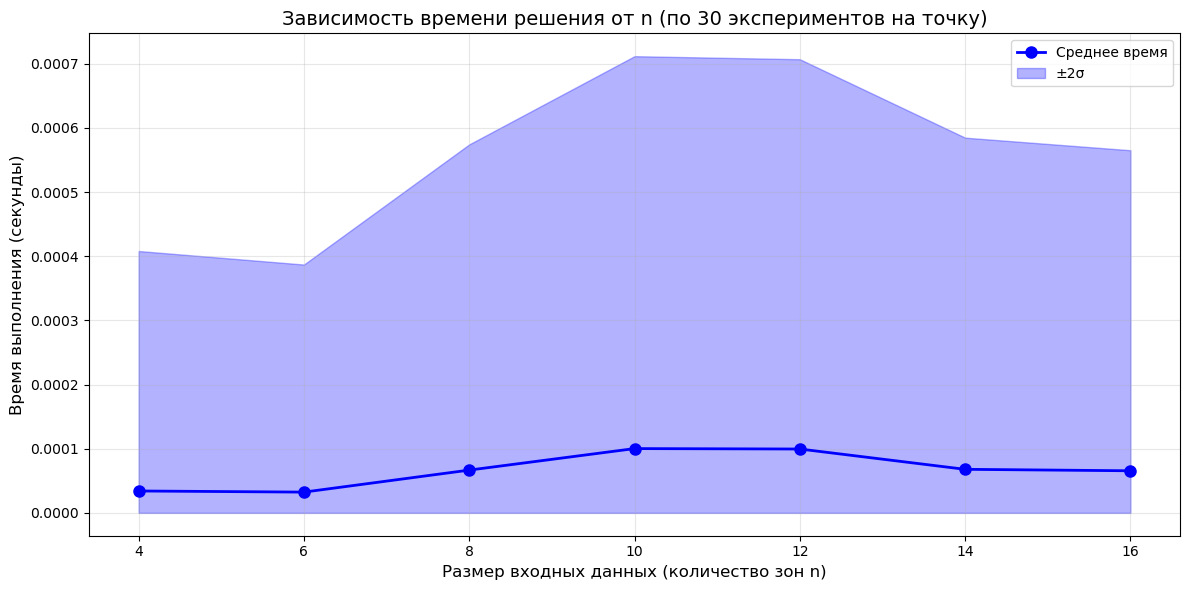

In [25]:
# БЛОК 8: ЭТАП 2 - График зависимости времени от n
def plot_time_vs_n(n_values=[4, 6, 8, 10, 12, 14, 16], experiments_per_n=30):
    """
    Строит график зависимости среднего времени от размера входных данных n
    """
    print(f"\n{'='*50}")
    print(f"ЗАВИСИМОСТЬ ВРЕМЕНИ ОТ РАЗМЕРА ВХОДНЫХ ДАННЫХ")
    print(f"{'='*50}")
    
    mean_times = []
    std_times = []
    
    for n in n_values:
        print(f"\nТестирование n = {n}...")
        times = []
        max_moves = min(6, n // 2)
        for _ in range(experiments_per_n):
            elapsed, _, _ = play_game_once(n, max_moves_per_player=max_moves, verbose=False)
            times.append(elapsed)
        
        mean_times.append(np.mean(times))
        std_times.append(np.std(times, ddof=1))
        print(f"  Среднее: {mean_times[-1]:.6f} сек, СКО: {std_times[-1]:.6f} сек")
    
    # Построение графика
    plt.figure(figsize=(12, 6))
    
    plt.plot(n_values, mean_times, 'b-', marker='o', linewidth=2, markersize=8, label='Среднее время')
    
    # Трубка ±2σ
    upper_bound = [mean_times[i] + 2 * std_times[i] for i in range(len(n_values))]
    lower_bound = [max(0, mean_times[i] - 2 * std_times[i]) for i in range(len(n_values))]
    plt.fill_between(n_values, lower_bound, upper_bound, alpha=0.3, color='blue', label='±2σ')
    
    plt.xlabel('Размер входных данных (количество зон n)', fontsize=12)
    plt.ylabel('Время выполнения (секунды)', fontsize=12)
    plt.title(f'Зависимость времени решения от n (по {experiments_per_n} экспериментов на точку)', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return n_values, mean_times, std_times

# Запуск этапа 2
n_values = [4, 6, 8, 10, 12, 14, 16]
n_vals, mean_vals, std_vals = plot_time_vs_n(n_values, experiments_per_n=30)


ГИСТОГРАММА ВРЕМЕНИ ДЛЯ n = 20
Количество экспериментов: 200
Выполнено 50 экспериментов...
Выполнено 100 экспериментов...
Выполнено 150 экспериментов...
Выполнено 200 экспериментов...

Статистика для n = 20:
  Среднее: 0.000135 сек
  Медиана: 0.000000 сек
  СКО: 0.000343 сек
  Минимум: 0.000000 сек
  Максимум: 0.001030 сек
  Q1 (25%): 0.000000 сек
  Q3 (75%): 0.000000 сек


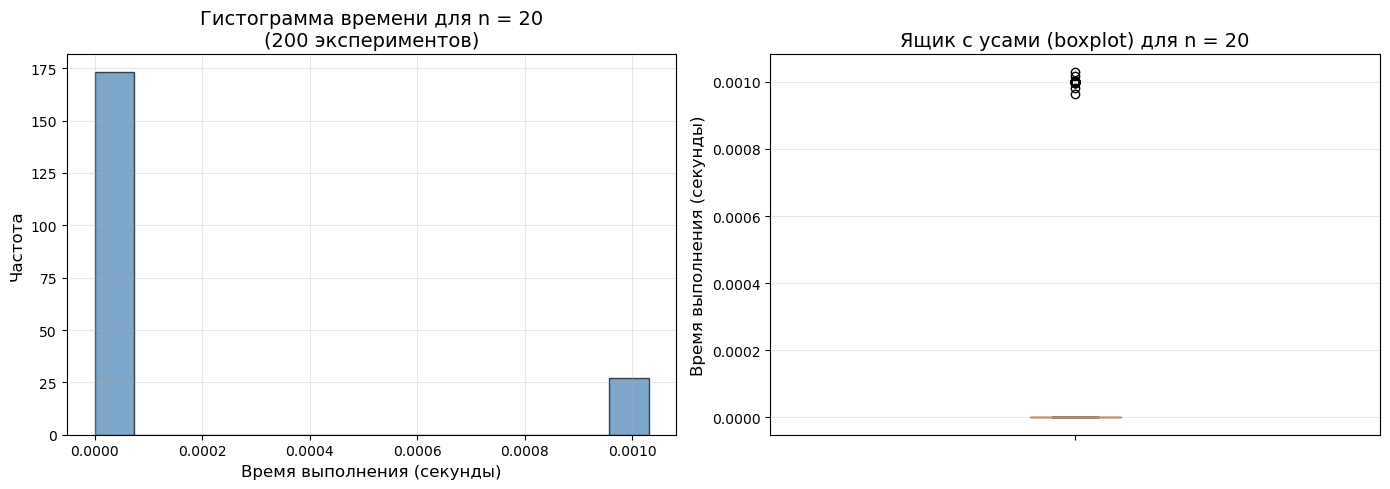

In [26]:
# БЛОК 9: ЭТАП 3 - Гистограмма для выбранного n
def plot_histogram_for_n(n_chosen=20, num_experiments=200):
    """
    Строит гистограмму времени выполнения для фиксированного n
    """
    print(f"\n{'='*50}")
    print(f"ГИСТОГРАММА ВРЕМЕНИ ДЛЯ n = {n_chosen}")
    print(f"Количество экспериментов: {num_experiments}")
    print(f"{'='*50}")
    
    times = []
    max_moves = min(6, n_chosen // 2)
    
    for i in range(num_experiments):
        elapsed, _, _ = play_game_once(n_chosen, max_moves_per_player=max_moves, verbose=False)
        times.append(elapsed)
        if (i + 1) % 50 == 0:
            print(f"Выполнено {i + 1} экспериментов...")
    
    # Построение гистограммы
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    n_bins = int(np.sqrt(num_experiments))
    plt.hist(times, bins=n_bins, edgecolor='black', alpha=0.7, color='steelblue')
    plt.xlabel('Время выполнения (секунды)', fontsize=12)
    plt.ylabel('Частота', fontsize=12)
    plt.title(f'Гистограмма времени для n = {n_chosen}\n({num_experiments} экспериментов)', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    bp = plt.boxplot(times, vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    plt.ylabel('Время выполнения (секунды)', fontsize=12)
    plt.title(f'Ящик с усами (boxplot) для n = {n_chosen}', fontsize=14)
    plt.xticks([1], [''])
    plt.grid(True, alpha=0.3, axis='y')
    
    print(f"\nСтатистика для n = {n_chosen}:")
    print(f"  Среднее: {np.mean(times):.6f} сек")
    print(f"  Медиана: {np.median(times):.6f} сек")
    print(f"  СКО: {np.std(times, ddof=1):.6f} сек")
    print(f"  Минимум: {np.min(times):.6f} сек")
    print(f"  Максимум: {np.max(times):.6f} сек")
    print(f"  Q1 (25%): {np.percentile(times, 25):.6f} сек")
    print(f"  Q3 (75%): {np.percentile(times, 75):.6f} сек")
    
    plt.tight_layout()
    plt.show()
    
    return times

# Запуск этапа 3
n_chosen = 20
hist_times = plot_histogram_for_n(n_chosen, num_experiments=200)


ПРОВЕРКА ГИПОТЕЗЫ О ЗАКОНЕ РАСПРЕДЕЛЕНИЯ ДЛЯ n = 10

Критерий Шапиро-Уилка:
  Статистика: 0.2245
  p-значение: 0.0000
  Вывод: Гипотеза о нормальном распределении отвергается (p ≤ 0.05)


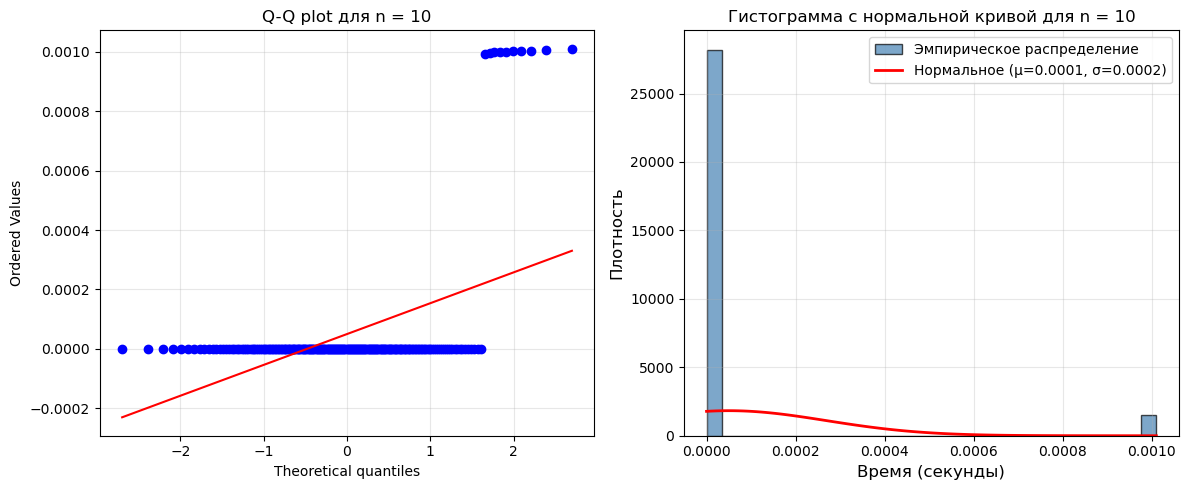

In [10]:
# БЛОК 10: ЭТАП 4 - Проверка гипотезы о законе распределения
def test_distribution(times, n_chosen):
    """
    Проверяет гипотезу о нормальном распределении
    """
    print(f"\n{'='*50}")
    print(f"ПРОВЕРКА ГИПОТЕЗЫ О ЗАКОНЕ РАСПРЕДЕЛЕНИЯ ДЛЯ n = {n_chosen}")
    print(f"{'='*50}")
    
    # Критерий Шапиро-Уилка (для нормальности)
    shapiro_stat, shapiro_p = stats.shapiro(times[:5000] if len(times) > 5000 else times)
    
    print(f"\nКритерий Шапиро-Уилка:")
    print(f"  Статистика: {shapiro_stat:.4f}")
    print(f"  p-значение: {shapiro_p:.4f}")
    
    if shapiro_p > 0.05:
        print("  Вывод: Нет оснований отвергнуть гипотезу о нормальном распределении (p > 0.05)")
    else:
        print("  Вывод: Гипотеза о нормальном распределении отвергается (p ≤ 0.05)")
    
    # Графики для визуальной проверки
    plt.figure(figsize=(12, 5))
    
    # Q-Q plot
    plt.subplot(1, 2, 1)
    stats.probplot(times, dist="norm", plot=plt)
    plt.title(f'Q-Q plot для n = {n_chosen}', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Гистограмма с кривой нормального распределения
    plt.subplot(1, 2, 2)
    plt.hist(times, bins=30, density=True, alpha=0.7, color='steelblue', 
             edgecolor='black', label='Эмпирическое распределение')
    
    mu = np.mean(times)
    sigma = np.std(times)
    x = np.linspace(min(times), max(times), 100)
    plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, 
             label=f'Нормальное (μ={mu:.4f}, σ={sigma:.4f})')
    
    plt.xlabel('Время (секунды)', fontsize=12)
    plt.ylabel('Плотность', fontsize=12)
    plt.title(f'Гистограмма с нормальной кривой для n = {n_chosen}', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Запуск этапа 4
test_distribution(hist_times, n_chosen)

In [11]:
# БЛОК 11: ЭТАП 5 - Оценка качества времени
def analyze_time_quality(n_values, mean_times, mean_time_for_n10, n_chosen=10):
    """
    Анализирует качество времени выполнения
    """
    print("\n" + "💡" * 15)
    print("ЭТАП 5: Оценка качества времени выполнения")
    print("💡" * 15)
    
    # Анализ сложности
    x_data = np.array(n_values)
    y_data = np.array(mean_times)
    
    def linear_func(x, a, b):
        return a * x + b
    
    def quadratic_func(x, a, b, c):
        return a * x**2 + b * x + c
    
    # Линейная аппроксимация
    popt_lin, _ = curve_fit(linear_func, x_data, y_data)
    r2_lin = 1 - np.sum((y_data - linear_func(x_data, *popt_lin))**2) / np.sum((y_data - np.mean(y_data))**2)
    
    # Квадратичная аппроксимация
    popt_quad, _ = curve_fit(quadratic_func, x_data, y_data)
    r2_quad = 1 - np.sum((y_data - quadratic_func(x_data, *popt_quad))**2) / np.sum((y_data - np.mean(y_data))**2)
    
    print(f"\nАнализ временной сложности:")
    print(f"  Линейная аппроксимация: y = {popt_lin[0]:.4f}·x + {popt_lin[1]:.4f}, R² = {r2_lin:.4f}")
    print(f"  Квадратичная аппроксимация: y = {popt_quad[0]:.4f}·x² + {popt_quad[1]:.4f}·x + {popt_quad[2]:.4f}, R² = {r2_quad:.4f}")
    
    if r2_quad > r2_lin:
        print(f"  Сложность близка к O(n²)")
    else:
        print(f"  Сложность близка к O(n)")
    
    print(f"\nВывод о качестве времени:")
    print(f"  • Среднее время для n={n_chosen}: {mean_time_for_n10:.6f} сек")
    print(f"  • Время растет {('квадратично' if r2_quad > r2_lin else 'линейно')} с увеличением n")
    
    if mean_time_for_n10 < 0.1:
        print(f"  • Время выполнения является ХОРОШИМ - алгоритм работает быстро (менее 0.1 сек для n={n_chosen})")
        print(f"    Для практических целей этого достаточно")
    elif mean_time_for_n10 < 0.5:
        print(f"  • Время выполнения является УДОВЛЕТВОРИТЕЛЬНЫМ - алгоритм работает достаточно быстро")
    else:
        print(f"  • Время выполнения является НЕДОСТАТОЧНО ХОРОШИМ - требуется оптимизация")
    
    return r2_lin, r2_quad

# Запуск этапа 5
r2_lin, r2_quad = analyze_time_quality(n_vals, mean_vals, mean_time, n_chosen=10)


💡💡💡💡💡💡💡💡💡💡💡💡💡💡💡
ЭТАП 5: Оценка качества времени выполнения
💡💡💡💡💡💡💡💡💡💡💡💡💡💡💡

Анализ временной сложности:
  Линейная аппроксимация: y = 0.0000·x + -0.0000, R² = 0.7787
  Квадратичная аппроксимация: y = 0.0000·x² + -0.0000·x + 0.0001, R² = 0.9351
  Сложность близка к O(n²)

Вывод о качестве времени:
  • Среднее время для n=10: 0.000060 сек
  • Время растет квадратично с увеличением n
  • Время выполнения является ХОРОШИМ - алгоритм работает быстро (менее 0.1 сек для n=10)
    Для практических целей этого достаточно


In [12]:
# БЛОК 12: Демонстрация визуализации одной игры (опционально)
# Запускаем одну игру с визуализацией графа
def play_and_visualize(n_zones=10, max_moves_per_player=4):
    """
    Запускает одну игру и показывает визуализацию
    """
    print("\n" + "="*50)
    print("ДЕМОНСТРАЦИЯ РАБОТЫ АЛГОРИТМА")
    print("="*50)
    
    start_time = time.time()
    
    graph, zone_values, occupied = initialize_game(n_zones)
    print(f"\nСгенерирован граф из {n_zones} зон")
    
    players = [1, 2]
    current = 0
    scores = {1: 0, 2: 0}
    moves = 0
    total_moves = max_moves_per_player * 2
    
    while moves < total_moves:
        player = players[current]
        zone, value = find_best_move(graph, zone_values, occupied, player)
        
        if zone is None:
            print(f"У игрока P{player} нет ходов!")
            break
        
        occupied[zone] = player
        scores[player] += value
        print(f"Ход {moves+1}: P{player} → зона {zone} (ценность {value})")
        
        current = (current + 1) % 2
        moves += 1
    
    print(f"\nРезультат: P1 = {scores[1]}, P2 = {scores[2]}")
    print(f"Время: {time.time() - start_time:.4f} сек")
    
    # Визуализация финального состояния
    visualize_graph(graph, zone_values, occupied, "Финальное состояние графа")
    
    return scores[1], scores[2]

# Запуск демонстрации (опционально)
# play_and_visualize(n_zones=8, max_moves_per_player=4)

In [13]:
# БЛОК 13: Сводный отчет
print("\n" + "="*60)
print("СВОДНЫЙ ОТЧЕТ ПО АНАЛИЗУ ВРЕМЕНИ")
print("="*60)

print(f"""
Результаты анализа алгоритма конкурентного размещения:

1. Эмпирическая оценка (n=10):
   • Математическое ожидание: {mean_time:.6f} сек
   • СКО: {np.std(times_fixed, ddof=1):.6f} сек
   • Коэффициент вариации: {np.std(times_fixed, ddof=1)/mean_time:.4f}

2. Характер зависимости от n:
   • Линейная аппроксимация: R² = {r2_lin:.4f}
   • Квадратичная аппроксимация: R² = {r2_quad:.4f}
   • Преобладающая сложность: {'O(n²)' if r2_quad > r2_lin else 'O(n)'}

3. Распределение времени:
   • Тест Шапиро-Уилка p-value: {stats.shapiro(hist_times[:5000])[1]:.4f}
   • Гипотеза о нормальном распределении: {'подтверждается' if stats.shapiro(hist_times[:5000])[1] > 0.05 else 'отвергается'}

4. Оценка качества:
   • Время выполнения {'является ХОРОШИМ' if mean_time < 0.1 else 'требует оптимизации'}
""")


СВОДНЫЙ ОТЧЕТ ПО АНАЛИЗУ ВРЕМЕНИ

Результаты анализа алгоритма конкурентного размещения:

1. Эмпирическая оценка (n=10):
   • Математическое ожидание: 0.000060 сек
   • СКО: 0.000238 сек
   • Коэффициент вариации: 3.9781

2. Характер зависимости от n:
   • Линейная аппроксимация: R² = 0.7787
   • Квадратичная аппроксимация: R² = 0.9351
   • Преобладающая сложность: O(n²)

3. Распределение времени:
   • Тест Шапиро-Уилка p-value: 0.0000
   • Гипотеза о нормальном распределении: отвергается

4. Оценка качества:
   • Время выполнения является ХОРОШИМ

